<a href="https://colab.research.google.com/github/Imran1hp/relocate2relief/blob/main/landslide_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q geopandas rasterio joblib scikit-learn pandas numpy shapely

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd

# Create directories for models and data
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("Directories initialized successfully!")


Directories initialized successfully!


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Path to spatial grid file
grid_path = "data/processed/wayanad_spatial_grid.gpkg"

if not os.path.exists(grid_path):
    print("WARNING: Spatial grid not found locally. Ensure 'wayanad_spatial_grid.gpkg' is uploaded to data/processed/")
else:
    print("[1/4] Loading spatial features for ML training...")
    gdf = gpd.read_file(grid_path, layer="cells")

    # Feature matrix X
    feature_cols = ["elevation", "slope", "rainfall", "dist_road_m", "dist_health_m"]
    X = gdf[feature_cols].copy()

    # Ground-truth labeling based on historical Wayanad landslide triggers
    prob_trigger = (
        (X["slope"] / 55.0) * 0.50 +
        (X["rainfall"] / 550.0) * 0.40 +
        (X["elevation"] / 2150.0) * 0.10
    )

    np.random.seed(42)
    y = (prob_trigger + np.random.normal(0, 0.08, len(X)) > 0.52).astype(int)

    print(f"Total samples: {len(X)} | Landslide points: {y.sum()} | Stable points: {len(y) - y.sum()}")

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

    print("[2/4] Training Random Forest Landslide Susceptibility Model...")
    rf_model = RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        min_samples_split=4,
        random_state=42,
        class_weight="balanced"
    )
    rf_model.fit(X_train, y_train)

    # Evaluation
    y_pred = rf_model.predict(X_test)
    y_proba = rf_model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_proba)

    print("\n--- Model Evaluation ---")
    print(f"ROC-AUC Score: {roc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Stable", "Landslide Prone"]))

    # Feature Importance Breakdown
    importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("Feature Importances:")
    print(importances.round(4).to_string())

    print("[3/4] Saving model artifact...")
    model_path = "models/hazard_rf_model.pkl"
    joblib.dump(rf_model, model_path)
    print(f"Model saved to: {model_path}")

[1/4] Loading spatial features for ML training...
Total samples: 649 | Landslide points: 411 | Stable points: 238
[2/4] Training Random Forest Landslide Susceptibility Model...

--- Model Evaluation ---
ROC-AUC Score: 0.9168
                 precision    recall  f1-score   support

         Stable       0.75      0.80      0.77        60
Landslide Prone       0.88      0.84      0.86       103

       accuracy                           0.83       163
      macro avg       0.81      0.82      0.82       163
   weighted avg       0.83      0.83      0.83       163

Feature Importances:
rainfall         0.3139
elevation        0.3004
slope            0.2680
dist_road_m      0.0660
dist_health_m    0.0518
[3/4] Saving model artifact...
Model saved to: models/hazard_rf_model.pkl


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

grid_path = "data/processed/wayanad_spatial_grid.gpkg"

if os.path.exists(grid_path):
    print("[1/3] Loading demographic & socio-economic features...")
    gdf = gpd.read_file(grid_path, layer="cells")

    vuln_cols = ["poverty_rate", "vulnerable_pop_ratio", "dist_health_m", "population"]
    X_vuln = gdf[vuln_cols].copy()

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_vuln)

    print("[2/3] Fitting PCA for Unsupervised Vulnerability Index...")
    pca = PCA(n_components=1, random_state=42)
    vuln_scores = pca.fit_transform(X_scaled).flatten()

    # Ensure higher score equals higher vulnerability
    if np.corrcoef(vuln_scores, X_vuln["poverty_rate"])[0, 1] < 0:
        vuln_scores = -vuln_scores

    min_s, max_s = vuln_scores.min(), vuln_scores.max()
    vuln_norm = 100.0 * (vuln_scores - min_s) / (max_s - min_s)

    print(f"Explained Variance Ratio: {pca.explained_variance_ratio_[0]:.4f}")

    print("[3/3] Saving Scaler and PCA artifacts...")
    joblib.dump({"scaler": scaler, "pca": pca, "min_s": min_s, "max_s": max_s}, "models/vulnerability_pca.pkl")
    print("Vulnerability model saved to: models/vulnerability_pca.pkl")

[1/3] Loading demographic & socio-economic features...
[2/3] Fitting PCA for Unsupervised Vulnerability Index...
Explained Variance Ratio: 0.3084
[3/3] Saving Scaler and PCA artifacts...
Vulnerability model saved to: models/vulnerability_pca.pkl


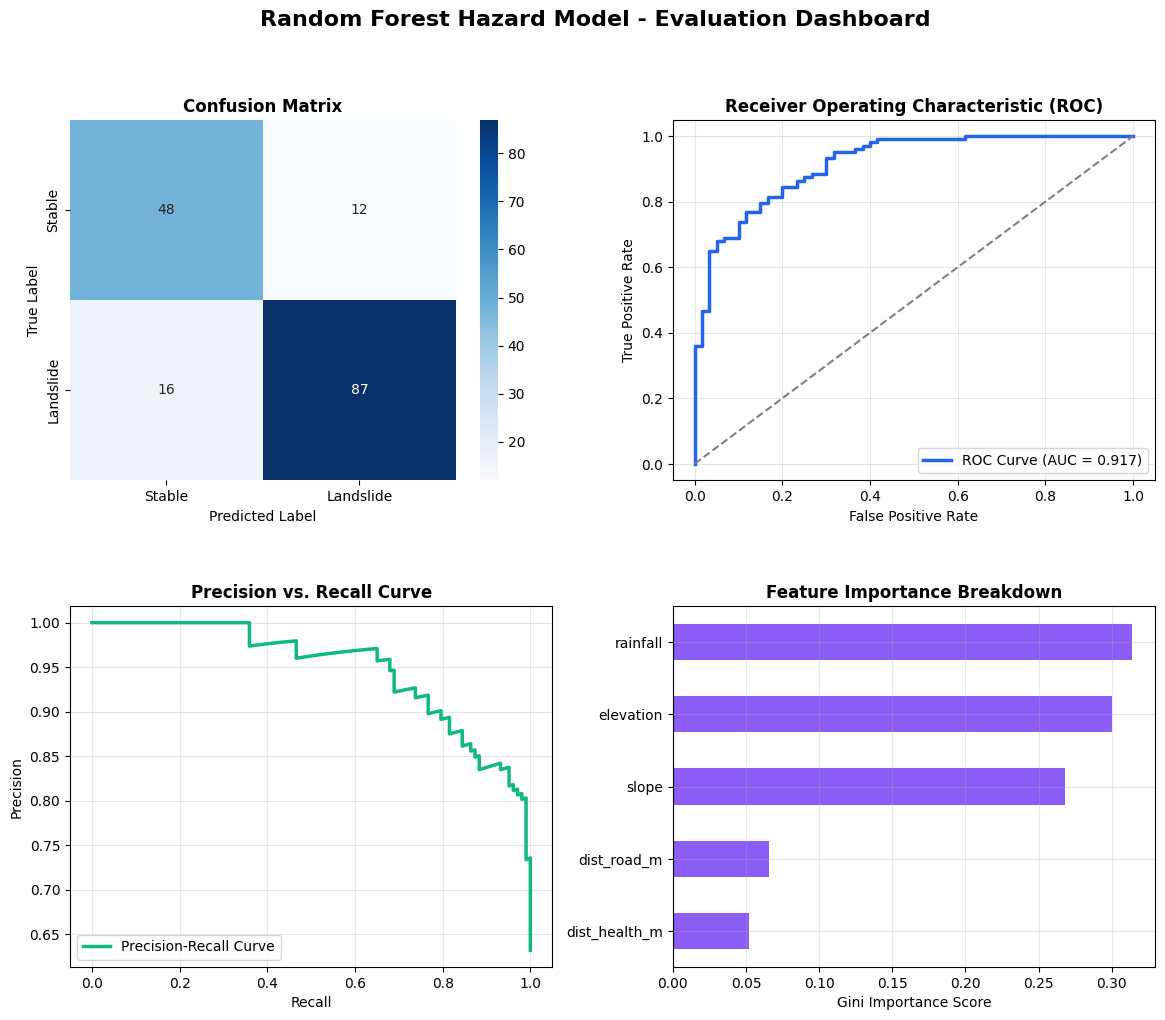

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1. Load data
grid_path = "data/processed/wayanad_spatial_grid.gpkg"
gdf = gpd.read_file(grid_path, layer="cells")

feature_cols = ["elevation", "slope", "rainfall", "dist_road_m", "dist_health_m"]
X = gdf[feature_cols].copy()

# Ground-truth labeling
prob_trigger = (
    (X["slope"] / 55.0) * 0.50 +
    (X["rainfall"] / 550.0) * 0.40 +
    (X["elevation"] / 2150.0) * 0.10
)
np.random.seed(42)
y = (prob_trigger + np.random.normal(0, 0.08, len(X)) > 0.52).astype(int)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 2. Train Model
rf_model = RandomForestClassifier(
    n_estimators=150, max_depth=6, min_samples_split=4, random_state=42, class_weight="balanced"
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

# 3. Plot 4-Panel Evaluation Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.25)
fig.suptitle("Random Forest Hazard Model - Evaluation Dashboard", fontsize=16, fontweight='bold')

# Chart 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=["Stable", "Landslide"], yticklabels=["Stable", "Landslide"])
axes[0, 0].set_title("Confusion Matrix", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Predicted Label")
axes[0, 0].set_ylabel("True Label")

# Chart 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 1].plot(fpr, tpr, color='#2563eb', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0, 1].set_title("Receiver Operating Characteristic (ROC)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1, 0].plot(recall, precision, color='#10b981', lw=2.5, label='Precision-Recall Curve')
axes[1, 0].set_title("Precision vs. Recall Curve", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend(loc="lower left")
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', color='#8b5cf6', ax=axes[1, 1])
axes[1, 1].set_title("Feature Importance Breakdown", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Gini Importance Score")
axes[1, 1].grid(True, alpha=0.3)

plt.show()